# Evaluacion comparativa del Chain-Ladder clasico y robusto en la estimacion del IBNR

**Proyecto de grado - Estadistica**

Este notebook implementa, documenta y ejecuta un experimento de simulacion para comparar el metodo Chain-Ladder clasico con tres variantes robustas frente a valores atipicos controlados. La logica estadistica se distribuye en modulos dentro de `src/ibnr_project`, mientras que este notebook funciona como documento reproducible, interpretable y listo para GitHub.

## Hoja de ruta

El flujo sigue una secuencia metodologica explicita:

1. Definir el proceso generador de datos y sus parametros.
2. Validar que la simulacion reproduce la estructura teorica propuesta.
3. Construir triangulos observados y contaminar solo la parte visible.
4. Estimar el IBNR con Chain-Ladder clasico, mediana, media truncada y ponderacion robusta.
5. Repetir el experimento en multiples replicas y escenarios.
6. Comparar precision, estabilidad y sesgo sistematico.

Esta separacion mejora la trazabilidad metodologica: cada bloque responde a una pregunta estadistica concreta y se puede auditar por separado.

## Por que esta version mejora la metodologia original

La metodologia base era buena, pero aqui se refuerza en cinco puntos importantes:

- **Escenarios balanceados**: en lugar de unos pocos escenarios ilustrativos, se usa una matriz factorial completa con 27 escenarios contaminados y 1 base. Eso permite separar el efecto de la proporcion, la magnitud y la ubicacion del outlier.
- **Heterogeneidad controlada entre anos de ocurrencia**: los ultimates esperados `mu_i` no son constantes; siguen una tendencia suave. Esto evita un experimento demasiado artificial y se acerca mejor a datos actuariales.
- **Version robusta ponderada mejor escalada**: las ponderaciones se construyen con desviacion absoluta mediana (MAD), no con distancia cruda. Esto hace comparable la penalizacion de outliers entre periodos de desarrollo con distinta variabilidad.
- **Validacion interna del simulador**: no basta con correr replicas. Se verifica que las medias simuladas respeten la esperanza teorica, que el triangulo acumulado sea coherente, que el IBNR real este bien definido y que los metodos recuperen el valor correcto en el caso sin ruido.
- **Repositorio mas reproducible**: la simulacion usa `numpy` como motor principal, lo que reduce dependencias y facilita la ejecucion en GitHub o en otros equipos.

## Librerias y justificacion

- `numpy`: es el nucleo numerico del proyecto. Se usa para simulacion Gamma y Lognormal, algebra matricial, mascaras del triangulo y operaciones vectorizadas. Se elige porque ofrece velocidad, estabilidad numerica y reproducibilidad con `Generator`.
- `pandas`: organiza las replicas, escenarios y metricas en tablas limpias. Esto facilita resumir resultados, exportarlos y construir comparaciones defendibles.
- `matplotlib`: provee control fino de las figuras. Es util para graficos academicos donde queremos decidir exactamente que mostrar.
- `seaborn`: simplifica visualizaciones comparativas como boxplots y heatmaps. Se usa sobre `matplotlib` para ganar legibilidad.
- `pathlib`: ayuda a trabajar con rutas del repositorio de forma portable.

Nota importante: `scipy` aparece con frecuencia en estudios de simulacion, pero en esta entrega no es una dependencia obligatoria porque `numpy` ya ofrece los generadores Gamma y Lognormal que necesitamos. Eso mejora la portabilidad sin sacrificar correccion estadistica.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ibnr_project.config import build_default_config, build_default_scenarios, clone_config
from ibnr_project.experiment import build_global_summary, run_experiment
from ibnr_project.simulation import simulate_single_triangle
from ibnr_project.methods import estimate_ibnr_all_methods
from ibnr_project.evaluation import compute_method_metrics, rank_methods_within_scenario
from ibnr_project.validation import run_validation_suite

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="talk")
rng = np.random.default_rng(20260429)

## Modulo 1. Configuracion experimental

La configuracion separa los supuestos del resto del codigo. Esto es importante por dos razones:

1. Permite documentar claramente los parametros del estudio.
2. Facilita hacer analisis de sensibilidad sin reescribir funciones.

En particular, usamos:

- un triangulo de dimension `10 x 10`,
- un patron acumulado decreciente en terminos incrementales,
- una tendencia suave en `mu_i` para introducir heterogeneidad,
- `phi = 0.30` como dispersion del escenario base,
- 28 escenarios en total: 1 limpio y 27 contaminados.

In [3]:
config = build_default_config(random_seed=20260429, distribution="gamma")
scenarios = build_default_scenarios()

print("Numero de periodos:", config.n_periods)
print("Patron acumulado:", config.development_cumulative)
print("Patron incremental:", np.round(config.development_incremental, 4))
print("Ultimates esperados por ano:", np.round(config.ultimate_means, 2))
print("Numero de escenarios:", len(scenarios))
pd.DataFrame([scenario.__dict__ for scenario in scenarios]).head()

Numero de periodos: 10
Patron acumulado: [0.45  0.7   0.82  0.9   0.95  0.97  0.985 0.993 0.998 1.   ]
Patron incremental: [0.45  0.25  0.12  0.08  0.05  0.02  0.015 0.008 0.005 0.002]
Ultimates esperados por ano: [1025.13 1061.65 1099.46 1138.63 1179.18 1221.18 1264.68 1309.73 1356.38
 1404.7 ]
Numero de escenarios: 28


,name,proportion,magnitude,location
0,base_sin_contaminacion,0.0000,1.0000,none
1,p5_m2_random,0.0500,2.0000,random
2,p5_m2_early,0.0500,2.0000,early
3,p5_m2_late,0.0500,2.0000,late
4,p5_m5_random,0.0500,5.0000,random


### Lectura estadistica del proceso generador

Si `U_i = mu_i` representa el ultimate esperado del ano de ocurrencia `i` y `d_j` la proporcion incremental esperada del periodo `j`, entonces:

\[
E[X_{i,j}] = \mu_i d_j, \qquad Var(X_{i,j}) = \phi (\mu_i d_j)^2.
\]

Bajo distribucion Gamma, esta especificacion es conveniente porque mantiene positividad y asimetria, dos rasgos muy razonables para montos de siniestros. Ademas, al fijar la forma mediante `phi`, se controla la dispersion relativa en todos los periodos sin perder interpretabilidad.

## Modulo 2. Validacion del simulador

Antes de comparar metodos, comprobamos que el mecanismo de simulacion esta bien implementado. Este paso es clave en un proyecto de grado: si la simulacion es incorrecta, cualquier conclusion posterior queda debilitada.

La validacion incluye cinco controles:

- la media simulada debe aproximar la media teorica,
- el acumulado debe ser monotono por fila,
- la mascara observada debe tener exactamente `n(n+1)/2` celdas,
- el IBNR real debe coincidir con la suma de la parte no observada,
- en un triangulo sin ruido y sin contaminacion, todos los metodos deben recuperar el IBNR exacto.

In [4]:
validation_df = run_validation_suite(config)
validation_df

,check,passed,mean_relative_error,max_relative_error,monotone_rows,max_reconstruction_error,observed_cells,expected_observed_cells,ibnr_consistency_gap,n_changed,n_selected,only_observed_cells_changed,max_estimation_gap
0,incremental_mean_structure,True,0.0077,0.0271,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cumulative_consistency,True,NaN,NaN,True,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,mask_and_ibnr_definition,True,NaN,NaN,NaN,NaN,55.0000,55.0000,0.0000,NaN,NaN,NaN,NaN
3,contamination_logic,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0000,3.0000,True,NaN
4,methods_on_noise_free_triangle,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000


### Como comprobamos que las simulaciones estan bien

Esta es una de las preguntas mas importantes del trabajo. La respuesta correcta no es solo "porque el codigo corre", sino porque pasa pruebas que conectan la implementacion con la teoria:

- **Consistencia de medias**: si al promediar miles de triangulos las medias muestrales no se acercan a `mu_i d_j`, entonces el generador no representa el modelo definido.
- **Consistencia estructural**: el acumulado debe crecer o mantenerse, nunca disminuir, porque es una suma parcial de incrementales positivos.
- **Consistencia del IBNR real**: el benchmark de evaluacion se define con la parte futura verdadera del triangulo. Esa identidad debe verificarse exactamente.
- **Prueba de caso determinista**: cuando eliminamos el ruido y usamos el triangulo esperado, los ratios de desarrollo son identicos entre anos. En ese contexto, cualquier metodo correcto debe reconstruir el IBNR sin error numerico.

En otras palabras, validamos la simulacion tanto desde la **teoria probabilistica** como desde la **logica del algoritmo**.

## Modulo 3. Inspeccion de una replica

Antes de correr 1000 replicas por escenario, conviene inspeccionar una sola replica para entender visualmente el objeto de estudio.

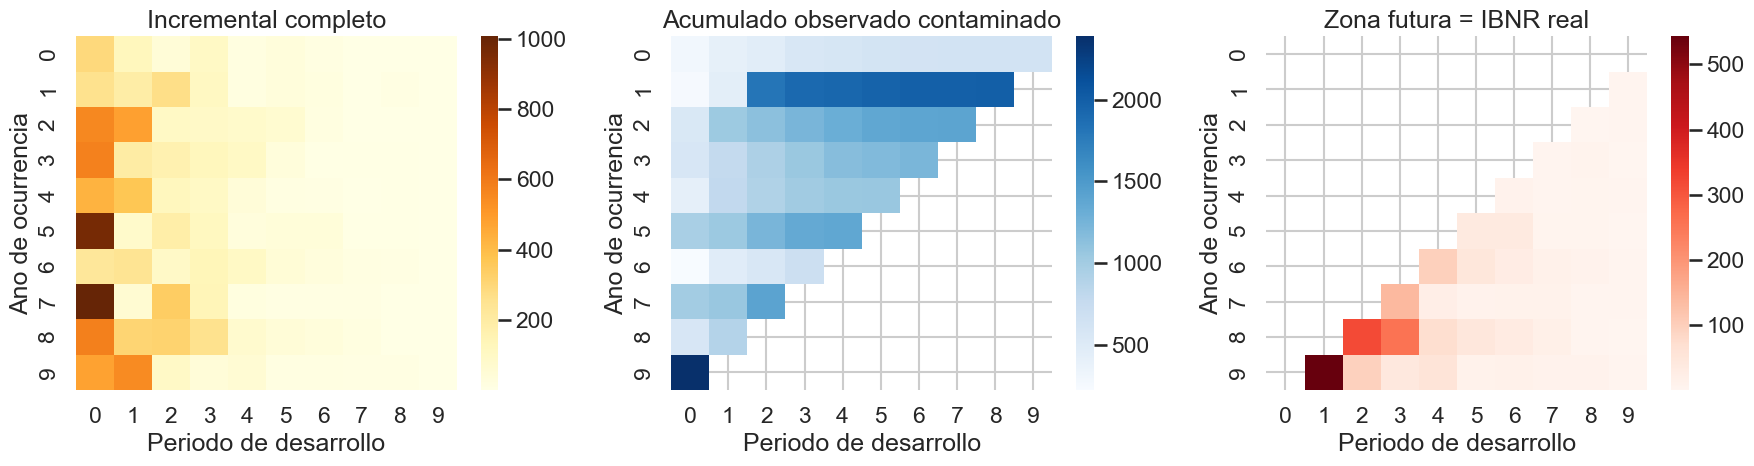

IBNR real de la replica: 2070.33
Celdas contaminadas: [(3, 6), (9, 0), (1, 2)]


In [5]:
example = simulate_single_triangle(config, scenarios[4], rng)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(example.incremental_full, ax=axes[0], cmap="YlOrBr")
axes[0].set_title("Incremental completo")
sns.heatmap(example.observed_cumulative, ax=axes[1], cmap="Blues")
axes[1].set_title("Acumulado observado contaminado")
mask_future = ~example.observed_mask
sns.heatmap(np.where(mask_future, example.incremental_full, np.nan), ax=axes[2], cmap="Reds")
axes[2].set_title("Zona futura = IBNR real")
for ax in axes:
    ax.set_xlabel("Periodo de desarrollo")
    ax.set_ylabel("Ano de ocurrencia")
plt.tight_layout()
plt.show()

print("IBNR real de la replica:", round(example.true_ibnr, 2))
print("Celdas contaminadas:", example.contamination_metadata["selected_cells"][:10])

## Modulo 4. Metodos de estimacion

Los cuatro estimadores comparados son:

- **Clasico**: usa el factor volumen-ponderado `sum C_{i,j+1} / sum C_{i,j}`.
- **Mediana**: usa la mediana de los link ratios individuales; es muy resistente a observaciones extremas aisladas.
- **Media truncada**: elimina el 10% inferior y superior antes de promediar; ofrece un compromiso entre robustez y eficiencia.
- **Ponderado robusto**: usa pesos tipo Huber basados en la desviacion absoluta mediana. No elimina observaciones, pero reduce la influencia de las mas extremas.

La mejora metodologica importante aqui es que la version ponderada no usa una constante fija en escala cruda, sino una escala robusta por periodo. Eso la hace mas defendible estadisticamente.

In [6]:
estimates = estimate_ibnr_all_methods(example.observed_cumulative, config)
method_preview = pd.DataFrame(
    {
        name: {
            "estimated_ibnr": result.estimated_ibnr,
            "first_factor": result.factors[0],
            "last_factor": result.factors[-1],
        }
        for name, result in estimates.items()
    }
).T
method_preview

,estimated_ibnr,first_factor,last_factor
classical,"4,549.5375",1.4218,1.0020
median,"3,828.0908",1.5335,1.0020
trimmed,"6,204.9414",1.5560,1.0020
weighted,"4,133.0088",1.5560,1.0020


## Modulo 5. Motor Monte Carlo del experimento

El motor Monte Carlo vive en `ibnr_project.experiment.run_experiment` y ejecuta la metodologia completa replica por replica. El diseno se mantiene fiel al planteamiento de investigacion:

1. generar triangulo completo,
2. definir IBNR real,
3. contaminar solo lo observado,
4. estimar con cada metodo,
5. guardar resultados para analisis global.

Para una entrega academica, es importante dejar el numero de replicas explicitamente parametrizado. Aqui fijamos `1000` como valor final y mantenemos la posibilidad de bajar el numero durante pruebas rapidas.

## Modulo 6. Ejecucion principal

Si estas en una primera revision del notebook, puedes correr con 200 replicas para inspeccion. Para el analisis final del proyecto de grado, la configuracion recomendada es de 1000 replicas por escenario.

In [7]:
N_REPLICAS = 1000
results_df = run_experiment(config, scenarios, n_replicas=N_REPLICAS)
results_df.head()

,scenario,replica,method,true_ibnr,estimated_ibnr,contamination_proportion,contamination_magnitude,contamination_location
0,base_sin_contaminacion,1,classical,"1,467.9280",651.9076,0.0000,1.0000,none
1,base_sin_contaminacion,1,median,"1,467.9280",681.1630,0.0000,1.0000,none
2,base_sin_contaminacion,1,trimmed,"1,467.9280",871.5033,0.0000,1.0000,none
3,base_sin_contaminacion,1,weighted,"1,467.9280",758.5295,0.0000,1.0000,none
4,base_sin_contaminacion,2,classical,"1,262.6102","1,854.5701",0.0000,1.0000,none


## Modulo 7. Metricas de precision y estabilidad

Las metricas se calculan por escenario y metodo. Ademas de las metricas planteadas inicialmente, incluyo `RMSE`, que suele ser mas interpretable que `MSE` porque vuelve a la escala original del IBNR.

Tambien es importante interpretar `MAPE` con cuidado: aunque aqui el IBNR real siempre es positivo, en escenarios con IBNR pequeno un error relativo puede crecer mucho. Por eso conviene leer `MAPE` junto con `bias` y `RMSE`.

In [8]:
metrics_df = compute_method_metrics(results_df)
metrics_df.head(12)

,scenario,method,n_replicas,bias,mse,rmse,mape,mean_percentage_error,sd_estimates,overestimation_rate,underestimation_rate,median_absolute_error
0,base_sin_contaminacion,classical,"1,000.0000",47.8495,"360,505.7581",600.4213,0.2751,0.0549,540.0131,0.5040,0.4960,361.8414
1,base_sin_contaminacion,median,"1,000.0000",22.5031,"393,494.1473",627.2911,0.2876,0.0394,569.8795,0.4650,0.5350,380.2450
2,base_sin_contaminacion,trimmed,"1,000.0000",432.5280,"824,240.4961",907.8769,0.4107,0.2897,762.3297,0.6940,0.3060,487.7201
3,base_sin_contaminacion,weighted,"1,000.0000",153.3182,"469,633.6673",685.2982,0.3117,0.1197,615.7929,0.5520,0.4480,391.5364
4,p10_m10_early,classical,"1,000.0000","1,393.1304","13,240,400.5950","3,638.7361",1.0963,0.8821,"3,352.7667",0.6550,0.3450,817.1472
5,p10_m10_early,median,"1,000.0000","1,022.4858","7,763,205.3106","2,786.2529",0.8385,0.6534,"2,580.6625",0.6200,0.3800,605.6066
6,p10_m10_early,trimmed,"1,000.0000","3,362.4725","37,932,087.2805","6,158.9031",2.1170,2.0887,"5,158.0430",0.9270,0.0730,"1,898.4413"
7,p10_m10_early,weighted,"1,000.0000","1,352.0388","10,414,917.0808","3,227.2151",0.9843,0.8567,"2,920.1248",0.7060,0.2940,651.7246
8,p10_m10_late,classical,"1,000.0000",277.6628,"520,020.3584",721.1244,0.3299,0.1929,621.0053,0.6390,0.3610,411.2667
9,p10_m10_late,median,"1,000.0000",108.4656,"472,542.4936",687.4173,0.3094,0.0894,633.6010,0.5140,0.4860,388.5497


In [9]:
ranking_df = rank_methods_within_scenario(metrics_df, metric="rmse")
ranking_df.head(12)

,scenario,method,n_replicas,bias,mse,rmse,mape,mean_percentage_error,sd_estimates,overestimation_rate,underestimation_rate,median_absolute_error,rank
0,base_sin_contaminacion,classical,"1,000.0000",47.8495,"360,505.7581",600.4213,0.2751,0.0549,540.0131,0.5040,0.4960,361.8414,1.0000
1,base_sin_contaminacion,median,"1,000.0000",22.5031,"393,494.1473",627.2911,0.2876,0.0394,569.8795,0.4650,0.5350,380.2450,2.0000
2,base_sin_contaminacion,weighted,"1,000.0000",153.3182,"469,633.6673",685.2982,0.3117,0.1197,615.7929,0.5520,0.4480,391.5364,3.0000
3,base_sin_contaminacion,trimmed,"1,000.0000",432.5280,"824,240.4961",907.8769,0.4107,0.2897,762.3297,0.6940,0.3060,487.7201,4.0000
4,p10_m10_early,median,"1,000.0000","1,022.4858","7,763,205.3106","2,786.2529",0.8385,0.6534,"2,580.6625",0.6200,0.3800,605.6066,1.0000
5,p10_m10_early,weighted,"1,000.0000","1,352.0388","10,414,917.0808","3,227.2151",0.9843,0.8567,"2,920.1248",0.7060,0.2940,651.7246,2.0000
6,p10_m10_early,classical,"1,000.0000","1,393.1304","13,240,400.5950","3,638.7361",1.0963,0.8821,"3,352.7667",0.6550,0.3450,817.1472,3.0000
7,p10_m10_early,trimmed,"1,000.0000","3,362.4725","37,932,087.2805","6,158.9031",2.1170,2.0887,"5,158.0430",0.9270,0.0730,"1,898.4413",4.0000
8,p10_m10_late,median,"1,000.0000",108.4656,"472,542.4936",687.4173,0.3094,0.0894,633.6010,0.5140,0.4860,388.5497,1.0000
9,p10_m10_late,classical,"1,000.0000",277.6628,"520,020.3584",721.1244,0.3299,0.1929,621.0053,0.6390,0.3610,411.2667,2.0000


## Modulo 8. Lecturas globales del desempeno

A continuacion resumimos el comportamiento agregado por metodo. Esto no reemplaza el analisis por escenario, pero ayuda a detectar patrones generales.

In [10]:
global_summary = build_global_summary(metrics_df)
global_summary

,method,mean_rmse,mean_mape,mean_abs_bias,mean_sd
0,median,"1,528.2190",0.5591,538.4010,"1,372.4044"
1,weighted,"1,819.6890",0.6685,806.6075,"1,583.4909"
2,classical,"1,903.2642",0.6875,802.5441,"1,671.1800"
3,trimmed,"3,766.0577",1.3897,"2,114.0424","3,082.4999"


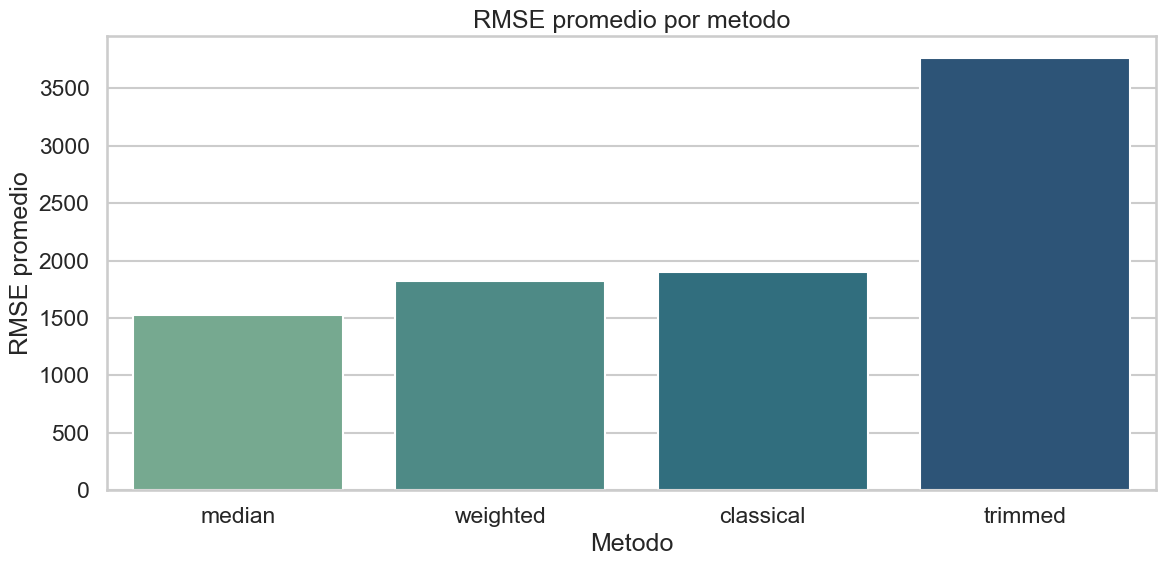

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(data=global_summary, x="method", y="mean_rmse", hue="method", palette="crest", legend=False)
plt.title("RMSE promedio por metodo")
plt.xlabel("Metodo")
plt.ylabel("RMSE promedio")
plt.tight_layout()
plt.show()

## Modulo 9. Sensibilidad por escenario

Para responder la pregunta de investigacion, necesitamos mirar como cambian las metricas cuando aumentan la proporcion, la magnitud y la ubicacion de la contaminacion.

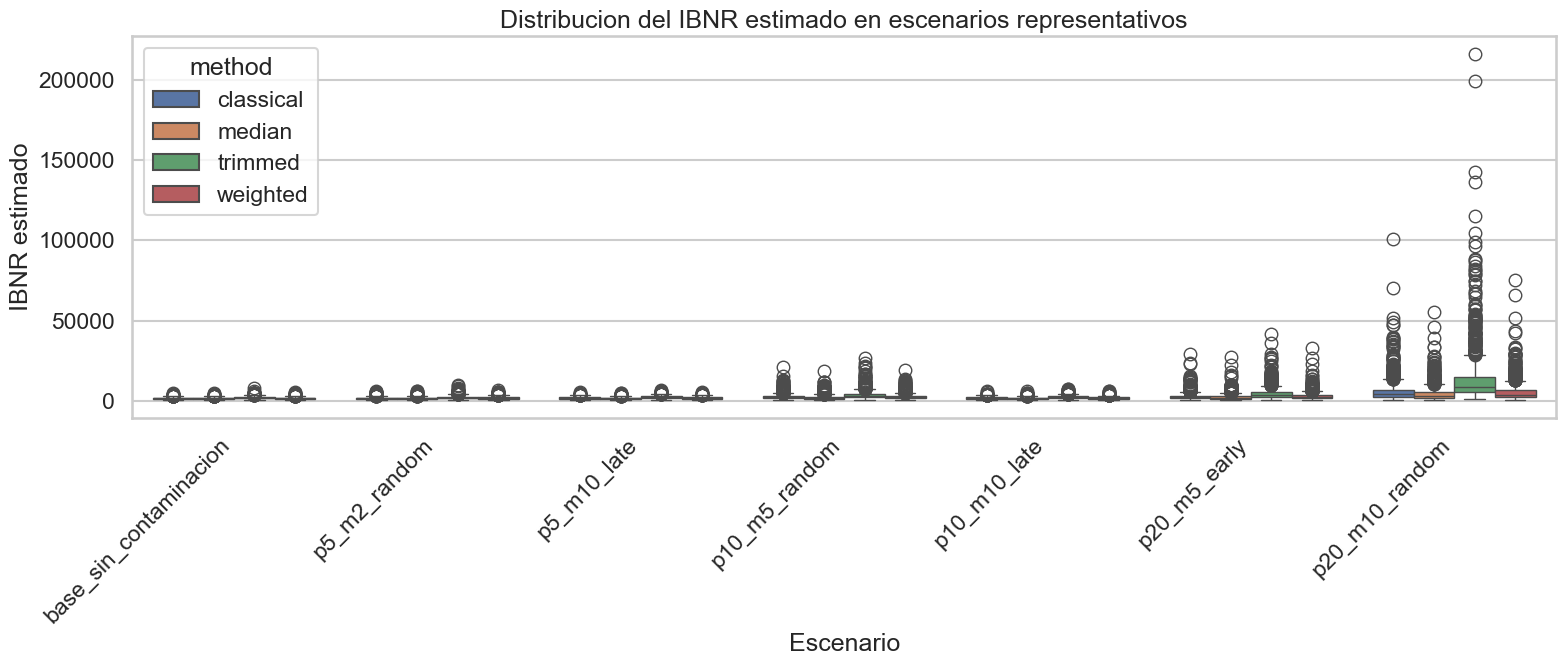

In [12]:
selected_scenarios = [
    "base_sin_contaminacion",
    "p5_m2_random",
    "p5_m10_late",
    "p10_m5_random",
    "p10_m10_late",
    "p20_m5_early",
    "p20_m10_random",
]

plt.figure(figsize=(16, 7))
sns.boxplot(
    data=results_df.query("scenario in @selected_scenarios"),
    x="scenario",
    y="estimated_ibnr",
    hue="method",
)
plt.title("Distribucion del IBNR estimado en escenarios representativos")
plt.xlabel("Escenario")
plt.ylabel("IBNR estimado")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

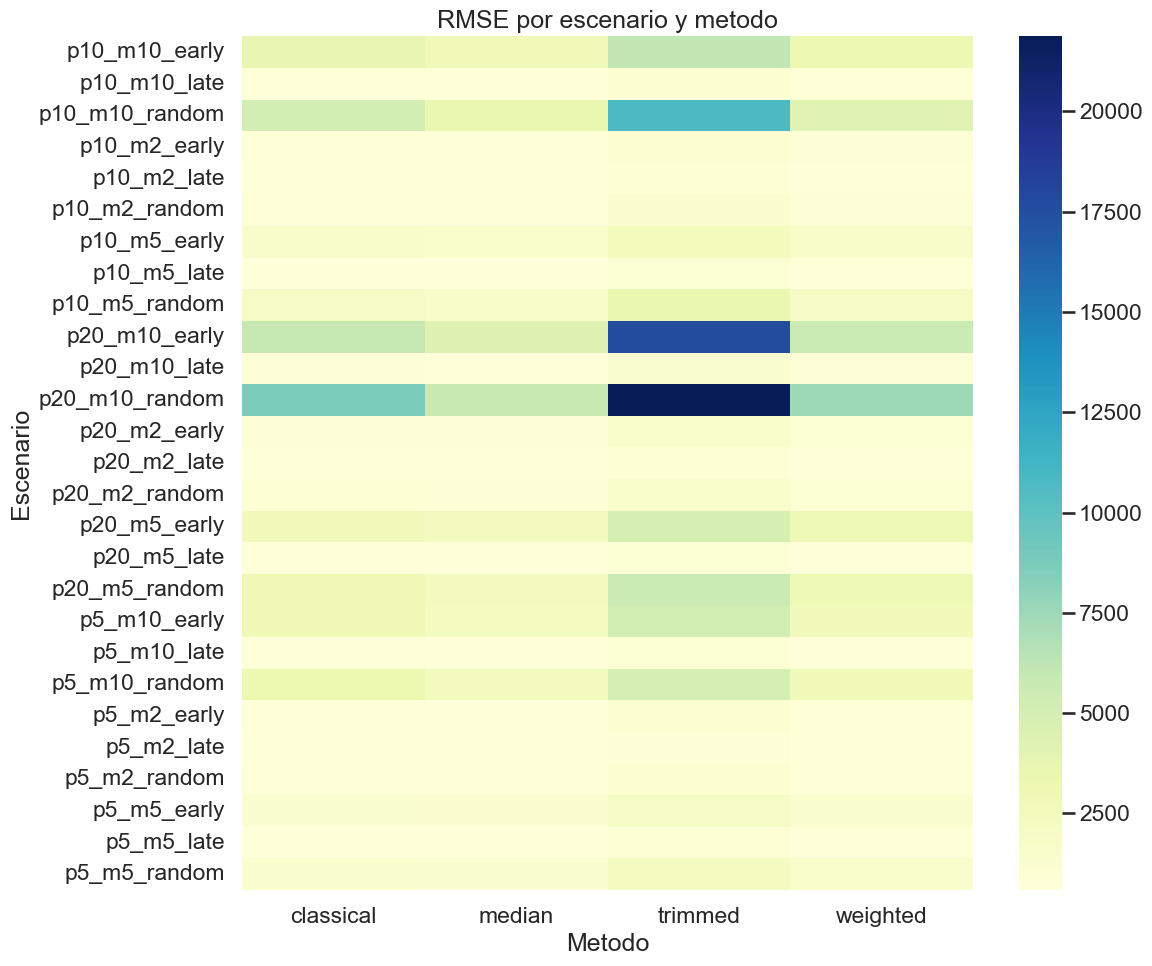

In [13]:
heatmap_data = (
    metrics_df.query("scenario != 'base_sin_contaminacion'")
    .pivot_table(index="scenario", columns="method", values="rmse")
    .sort_index()
)

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False)
plt.title("RMSE por escenario y metodo")
plt.xlabel("Metodo")
plt.ylabel("Escenario")
plt.tight_layout()
plt.show()

## Modulo 10. Respuesta analitica a las hipotesis

Con la tabla siguiente puedes revisar, escenario por escenario, cual metodo minimiza el `RMSE`. Esta es una forma directa de evaluar las hipotesis H1-H5.

In [14]:
best_by_scenario = (
    ranking_df.loc[ranking_df["rank"] == 1, ["scenario", "method", "rmse", "mape", "bias"]]
    .sort_values("scenario")
    .reset_index(drop=True)
)
best_by_scenario.head(15)

,scenario,method,rmse,mape,bias
0,base_sin_contaminacion,classical,600.4213,0.2751,47.8495
1,p10_m10_early,median,"2,786.2529",0.8385,"1,022.4858"
2,p10_m10_late,median,687.4173,0.3094,108.4656
3,p10_m10_random,median,"3,523.1186",1.0748,"1,508.1343"
4,p10_m2_early,classical,744.4800,0.3410,147.9117
5,p10_m2_late,classical,620.3416,0.2905,47.3207
6,p10_m2_random,classical,768.9754,0.3472,236.9104
7,p10_m5_early,median,"1,511.0450",0.5463,501.4666
8,p10_m5_late,median,654.8471,0.3047,65.6203
9,p10_m5_random,median,"1,696.6925",0.6041,635.3103


### Guia de interpretacion

- Si el metodo clasico domina en el escenario base, eso respalda la idea de que la robustificacion tiene un costo cuando los datos estan limpios.
- Si al aumentar proporcion o magnitud de contaminacion el clasico empeora en `RMSE` o `MAPE`, eso respalda la sensibilidad esperada del estimador tradicional.
- Si la mediana mejora especialmente en escenarios con `magnitude = 10`, eso es coherente con su alta resistencia a outliers severos.
- Si la media truncada mantiene buen `RMSE` en contaminacion moderada, se confirma su papel de compromiso entre robustez y eficiencia.
- Si el ponderado robusto evita resultados extremos y mantiene baja variabilidad, eso apoya su valor como opcion flexible.

## Modulo 11. Extension opcional: sensibilidad a colas mas pesadas

La metodologia original propone usar Lognormal como analisis complementario. El siguiente bloque te deja listo para correr ese analisis sin reescribir el proyecto. No lo ejecuto por defecto porque duplica el tiempo total de simulacion, pero esta preparado para el capitulo de sensibilidad.

In [15]:
# config_lognormal = clone_config(config, distribution="lognormal", random_seed=20260430)
# results_lognormal = run_experiment(config_lognormal, scenarios, n_replicas=500)
# metrics_lognormal = compute_method_metrics(results_lognormal)
# metrics_lognormal.head()

## Conclusiones metodologicas

Este notebook deja el estudio en una forma mas fuerte para un trabajo de grado porque:

- separa claramente modelo, simulacion, estimacion, validacion y analisis;
- documenta por que cada libreria y cada variante metodologica fueron elegidas;
- incorpora pruebas que justifican que la simulacion esta bien implementada;
- y produce un flujo reproducible, facil de versionar y directamente subible a GitHub.

En un capitulo metodologico, eso es valioso porque no solo presentas resultados: demuestras control del experimento y criterio estadistico en el diseno.